In [2]:
import tensorflow as tf
import numpy as np 

import warnings
warnings.filterwarnings('ignore')

print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


In [5]:
from PIL import Image
import glob
import os
import matplotlib.pyplot as plt

# 이미지 로드
img = Image.open('data/scissor/0.jpg')

# numpy 배열로 변환
img_array = np.array(img)

img_array.shape

(224, 224, 3)

In [39]:
# 28 X 28 크기로 Resize

def resize_images(img_path):
    images = glob.glob(img_path + '/*.jpg')

    print(len(images), " images to be resized.")

    target_size = (28,28)
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize(target_size, Image.LANCZOS)
        new_img.save(img, 'JPEG')
    
    print(len(images), " imgaes resized.")

image_dir_path = "data/scissor"
image_dir_path2 = "data/scissor2"

resize_images(image_dir_path)
resize_images(image_dir_path2)

print("가위 이미지 resize 완료!")

100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
가위 이미지 resize 완료!


In [40]:
# 바위
resize_images("data/rock")
resize_images("data/rock2")
print("바위 이미지 resize 완료!")

# 보
resize_images("data/paper")
resize_images("data/paper2")
print("보 이미지 resize 완료!")

100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
바위 이미지 resize 완료!
100  images to be resized.
100  imgaes resized.
100  images to be resized.
100  imgaes resized.
보 이미지 resize 완료!


All data shape: (300, 28, 28, 3)
All label shape: (300,)
label distribution: scissor=100, rock=100, paper=100


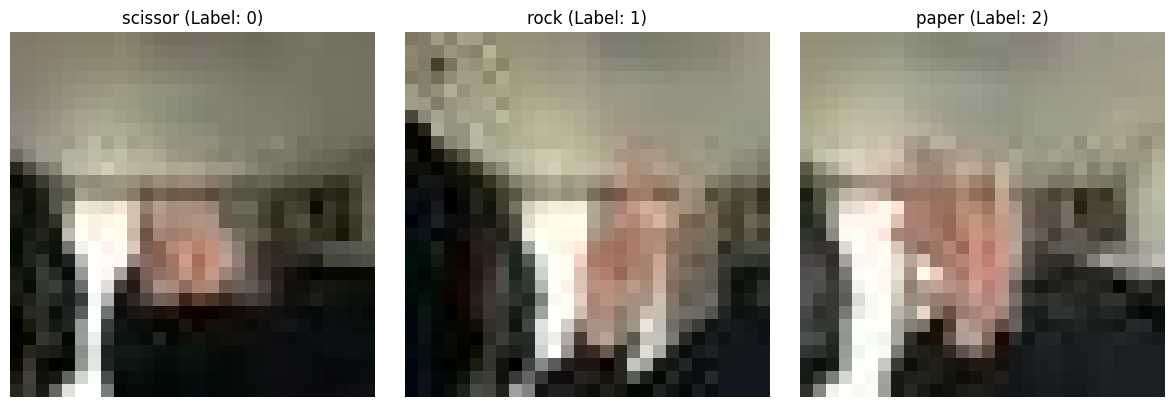

In [ ]:
# load_data 함수

def load_data(img_path, number_of_data = 300):

    img_size = 28
    color = 3

    imgs = np.zeros(number_of_data * img_size * img_size * color, dtype = np.int32).reshape(number_of_data, img_size, img_size, color)
    
    # 레이블 배열 초기화
    labels = np.zeros(number_of_data, dtype = np.int32)
    
    # 이미지 파일 읽기
    images = glob.glob(img_path + '/*.jpg')
    
    # 각 이미지를 배열에 저장
    for idx, img_file in enumerate(images[:number_of_data]):
        img = Image.open(img_file)
        imgs[idx] = np.array(img)
    
    return imgs, labels

# 가위, 바위, 보 데이터 로드

# 가위 (label: 0)
scissor_imgs, _ = load_data('data/scissor', 100)
scissor_labels = np.zeros(100, dtype=np.int32)

# 바위 (label: 1)
rock_imgs, _ = load_data('data/rock', 100)
rock_labels = np.ones(100, dtype=np.int32)

# 보 (label: 2)
paper_imgs, _ = load_data('data/paper', 100)
paper_labels = np.full(100, 2, dtype=np.int32)

# 모든 데이터 병합
X = np.concatenate([scissor_imgs, rock_imgs, paper_imgs], axis=0)
y = np.concatenate([scissor_labels, rock_labels, paper_labels], axis=0)

print(f"All data shape: {X.shape}")
print(f"All label shape: {y.shape}")
print(f"label distribution: scissor={np.sum(y==0)}, rock={np.sum(y==1)}, paper={np.sum(y==2)}")


# 데이터 시각화로 확인
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 각 클래스별로 하나씩 샘플 출력
axes[0].imshow(X[0])
axes[0].set_title(f'scissor (Label: {y[0]})')
axes[0].axis('off')

axes[1].imshow(X[100])
axes[1].set_title(f'rock (Label: {y[100]})')
axes[1].axis('off')

axes[2].imshow(X[200])
axes[2].set_title(f'paper (Label: {y[200]})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


All data shape: (300, 28, 28, 3)
All label shape: (300,)
label distribution: scissor=100, rock=100, paper=100


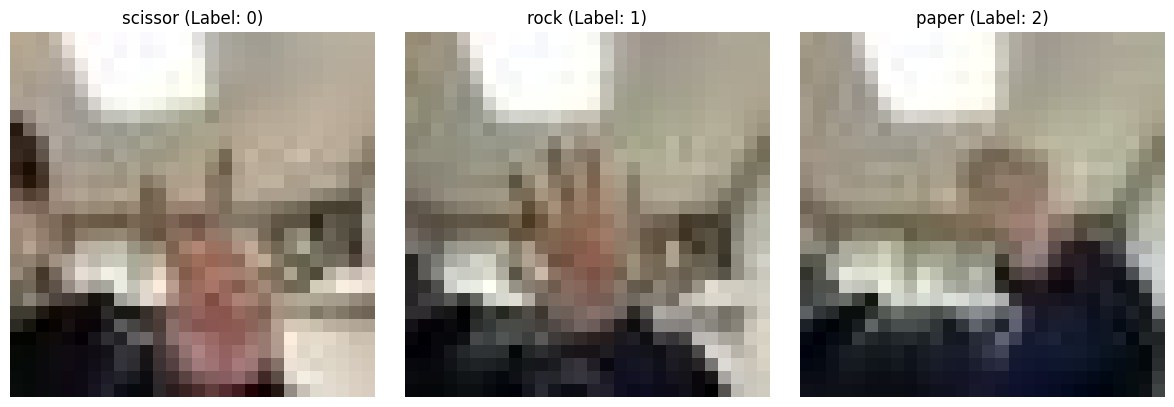

In [41]:
# 가위 (label: 0)
scissor2_imgs, _ = load_data('data/scissor2', 100)
scissor2_labels = np.zeros(100, dtype=np.int32)

# 바위 (label: 1)
rock2_imgs, _ = load_data('data/rock2', 100)
rock2_labels = np.ones(100, dtype=np.int32)

# 보 (label: 2)
paper2_imgs, _ = load_data('data/paper2', 100)
paper2_labels = np.full(100, 2, dtype=np.int32)

# 모든 데이터 병합
X2 = np.concatenate([scissor2_imgs, rock2_imgs, paper2_imgs], axis=0)
y2 = np.concatenate([scissor2_labels, rock2_labels, paper2_labels], axis=0)

print(f"All data shape: {X2.shape}")
print(f"All label shape: {y2.shape}")
print(f"label distribution: scissor={np.sum(y2==0)}, rock={np.sum(y2==1)}, paper={np.sum(y2==2)}")


# 데이터 시각화로 확인
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 각 클래스별로 하나씩 샘플 출력
axes[0].imshow(X2[0])
axes[0].set_title(f'scissor (Label: {y2[0]})')
axes[0].axis('off')

axes[1].imshow(X2[100])
axes[1].set_title(f'rock (Label: {y2[100]})')
axes[1].axis('off')

axes[2].imshow(X2[200])
axes[2].set_title(f'paper (Label: {y2[200]})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [45]:
n_channel_1 = 16
n_channel_2 = 32
n_dense = 32
n_train_epoch = 10

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3, 3), activation='relu', input_shape=(28, 28, 3)))
model.add(keras.layers.MaxPool2D(2, 2))
model.add(keras.layers.Conv2D(n_channel_2, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,819 (120.39 KB)

 Trainable params: 30,819 (120.39 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.fit(X,y, epochs = n_train_epoch)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4894 - loss: 13.4444  
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7592 - loss: 3.6361 
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9179 - loss: 0.5703 
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9775 - loss: 0.0893    
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.4132e-05
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.9228e-06
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.0569e-05
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.9461e-04
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.5887e-05
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.7160e-05


In [47]:
test_loss, test_accuracy = model.evaluate(X2, y2, verbose=2)
print("test_loss : {}".format(test_loss))
print("Test accuracy: {}".format(test_accuracy))

10/10 - 0s - 7ms/step - accuracy: 0.0833 - loss: 9.9012
test_loss : 9.901152610778809
Test accuracy: 0.0833333358168602


In [49]:
from sklearn.model_selection import train_test_split

# 1. 모든 데이터 합치기
X_total = np.concatenate([X, X2], axis=0)
y_total = np.concatenate([y, y2], axis=0)

print(f"전체 데이터 shape: {X_total.shape}")
print(f"전체 레이블 shape: {y_total.shape}")
print(f"레이블 분포: 가위={np.sum(y_total==0)}, 바위={np.sum(y_total==1)}, 보={np.sum(y_total==2)}")

# 2. 데이터 정규화 (0-255 -> 0-1)
X_total_normalized = X_total / 255.0

# 3. 훈련/테스트 셋으로 다시 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_total_normalized, 
    y_total, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_total  # 각 클래스 비율을 유지하면서 분할
)

print(f"\n새로운 훈련 데이터: {X_train.shape}, {y_train.shape}")
print(f"새로운 테스트 데이터: {X_test.shape}, {y_test.shape}")

# 각 세트의 레이블 분포 확인
print(f"\n훈련 세트 레이블 분포:")
print(f"  가위={np.sum(y_train==0)}, 바위={np.sum(y_train==1)}, 보={np.sum(y_train==2)}")
print(f"테스트 세트 레이블 분포:")
print(f"  가위={np.sum(y_test==0)}, 바위={np.sum(y_test==1)}, 보={np.sum(y_test==2)}")

전체 데이터 shape: (600, 28, 28, 3)
전체 레이블 shape: (600,)
레이블 분포: 가위=200, 바위=200, 보=200

새로운 훈련 데이터: (480, 28, 28, 3), (480,)
새로운 테스트 데이터: (120, 28, 28, 3), (120,)

훈련 세트 레이블 분포:
  가위=160, 바위=160, 보=160
테스트 세트 레이블 분포:
  가위=40, 바위=40, 보=40


In [50]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5611 - loss: 1.0564  
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7006 - loss: 1.0118
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8886 - loss: 0.9387
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8108 - loss: 0.8189
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9661 - loss: 0.6234
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9631 - loss: 0.4744
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9969 - loss: 0.3075
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.2042
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1314
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - loss: 0.0930


In [51]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print("test_loss : {}".format(test_loss))
print("Test accuracy: {}".format(test_accuracy))

4/4 - 0s - 15ms/step - accuracy: 1.0000 - loss: 0.0900
test_loss : 0.08997025340795517
Test accuracy: 1.0
